# 10. Inspect IPC food insecurity data

This notebook adds an IPC acute food insecurity vulnerability layer to the Mozambique ADM2 under-18 population baseline.

The main research question for this step is not just "can the tables be joined?" It is "which IPC layer can be joined responsibly to ADM2 districts without pretending that missing or mismatched IPC units are zero food insecurity?"

Inputs:

- `data/raw/ipc/ipc_moz_area_wide_latest.csv`
- `data/raw/ipc/ipc_moz_area_long_latest.csv`
- `data/raw/ipc/ipc_moz.geojson`
- `data/processed/moz_adm2_under18_2019.csv`
- `data/processed/moz_adm2_under18_2019.gpkg`

Outputs:

- `data/processed/moz_adm2_under18_ipc_current.csv`
- `data/processed/moz_adm2_under18_ipc_2022_safe.csv`
- `figures/moz_ipc_phase3plus_current_2026.png`

Interpretation rule: missing IPC values stay missing. They are not filled with zero, because missingness means the IPC source did not safely provide a comparable value for that ADM2 district.


## 1. Load libraries and input paths

This setup cell imports the geospatial and tabular libraries used throughout the notebook and defines the IPC raw-data paths from the project root. Keeping these paths explicit makes the notebook reproducible from a fresh kernel.


In [7]:
from pathlib import Path
import sys

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from childreach.paths import DATA_RAW

IPC_RAW_DIR = DATA_RAW / "ipc"

ipc_geojson_path = IPC_RAW_DIR / "ipc_moz.geojson"
ipc_area_wide_path = IPC_RAW_DIR / "ipc_moz_area_wide_latest.csv"
ipc_area_long_path = IPC_RAW_DIR / "ipc_moz_area_long_latest.csv"

for path in [ipc_geojson_path, ipc_area_wide_path, ipc_area_long_path]:
    print(path, "exists:", path.exists())


C:\Users\Cameron\Desktop\github\child_reach_spacial_project\data\raw\ipc\ipc_moz.geojson exists: True
C:\Users\Cameron\Desktop\github\child_reach_spacial_project\data\raw\ipc\ipc_moz_area_wide_latest.csv exists: True
C:\Users\Cameron\Desktop\github\child_reach_spacial_project\data\raw\ipc\ipc_moz_area_long_latest.csv exists: True


## 2. Load the latest IPC source files

This section reads the latest IPC wide table, long table, and GeoJSON. The first check is simply whether the files load and what shapes they have, because those shapes tell us how much information is available before any join is attempted.


In [2]:
ipc_area_wide = pd.read_csv(ipc_area_wide_path)
ipc_area_long = pd.read_csv(ipc_area_long_path)
ipc_geo = gpd.read_file(ipc_geojson_path)

print("Area wide shape:", ipc_area_wide.shape)
print("Area long shape:", ipc_area_long.shape)
print("GeoJSON shape:", ipc_geo.shape)


Area wide shape: (46, 50)
Area long shape: (644, 11)
GeoJSON shape: (46, 36)


## 3. Inspect the latest IPC table structure

Before selecting a vulnerability metric, inspect the column names, key administrative fields, time period, and Phase 3+ summary statistics. This confirms that `Phase 3+ percentage current` is available as a normalized severity metric and shows whether the latest dataset is national or partial.


In [3]:
ipc_area_wide.columns.tolist()


['Date of analysis',
 'Country',
 'Total country population',
 'Level 1',
 'Area',
 'Current from',
 'Current to',
 'Population analyzed current',
 'Phase 3+ number current',
 'Phase 3+ percentage current',
 'Phase 1 number current',
 'Phase 1 percentage current',
 'Phase 2 number current',
 'Phase 2 percentage current',
 'Phase 3 number current',
 'Phase 3 percentage current',
 'Phase 4 number current',
 'Phase 4 percentage current',
 'Phase 5 number current',
 'Phase 5 percentage current',
 'First projection from',
 'First projection to',
 'Population analyzed first projection',
 'Phase 3+ number first projection',
 'Phase 3+ percentage first projection',
 'Phase 1 number first projection',
 'Phase 1 percentage first projection',
 'Phase 2 number first projection',
 'Phase 2 percentage first projection',
 'Phase 3 number first projection',
 'Phase 3 percentage first projection',
 'Phase 4 number first projection',
 'Phase 4 percentage first projection',
 'Phase 5 number first project

In [4]:
ipc_area_wide[
    [
        "Date of analysis",
        "Level 1",
        "Area",
        "Current from",
        "Current to",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].head(10)


,Date of analysis,Level 1,Area,Current from,Current to,Population analyzed current,Phase 3+ number current,Phase 3+ percentage current
0,Jul 2026,Tete,Zumbu,2026-07-01,2026-09-30,103235,10324,0.10
1,Jul 2026,Tete,Cahora Bassa,2026-07-01,2026-09-30,184617,27693,0.15
2,Jul 2026,Tete,Doa,2026-07-01,2026-09-30,108081,27020,0.25
3,Jul 2026,Tete,Moatize,2026-07-01,2026-09-30,364637,54696,0.15
4,Jul 2026,Tete,Mutarara,2026-07-01,2026-09-30,222038,55510,0.25
5,Jul 2026,Gaza,Massingir,2026-07-01,2026-09-30,37844,5677,0.15
6,Jul 2026,Gaza,Chibuto,2026-07-01,2026-09-30,238148,47629,0.20
7,Jul 2026,Gaza,Chokwe,2026-07-01,2026-09-30,246617,36993,0.15
8,Jul 2026,Gaza,Chongoene,2026-07-01,2026-09-30,122383,12238,0.10
9,Jul 2026,Gaza,Guija,2026-07-01,2026-09-30,94271,14141,0.15


In [5]:
ipc_area_wide["Level 1"].dropna().sort_values().unique()


<StringArray>
['Cabo Delgado',         'Gaza',    'Inhambane',       'Manica',
       'Maputo',      'Nampula',       'Sofala',         'Tete',
     'Zambezia']
Length: 9, dtype: str

In [6]:
ipc_area_wide[["Level 1", "Area"]].drop_duplicates().head(25)


,Level 1,Area
0,Tete,Zumbu
1,Tete,Cahora Bassa
2,Tete,Doa
3,Tete,Moatize
4,Tete,Mutarara
5,Gaza,Massingir
6,Gaza,Chibuto
7,Gaza,Chokwe
8,Gaza,Chongoene
9,Gaza,Guija


In [7]:
ipc_area_wide["Phase 3+ percentage current"].describe()


count    46.000000
mean      0.155435
std       0.084478
min       0.050000
25%       0.100000
50%       0.150000
75%       0.187500
max       0.400000
Name: Phase 3+ percentage current, dtype: float64

## 4. Compare latest relative severity and absolute burden

The percentage metric identifies areas where the share of people in IPC Phase 3 or worse is highest. The number metric identifies where the absolute count of affected people is highest. Both are useful, but they answer different questions.


In [8]:
ipc_area_wide.sort_values(
    "Phase 3+ percentage current",
    ascending=False
)[
    [
        "Level 1",
        "Area",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].head(10)


,Level 1,Area,Population analyzed current,Phase 3+ number current,Phase 3+ percentage current
21,Cabo Delgado,Mocimboa Da Praia,170873,68349,0.40
17,Cabo Delgado,Macomia,150592,60237,0.40
14,Cabo Delgado,Quissanga,65017,22756,0.35
29,Sofala,Muanza,48987,14696,0.30
4,Tete,Mutarara,222038,55510,0.25
2,Tete,Doa,108081,27020,0.25
27,Sofala,Machanga,71588,17897,0.25
25,Sofala,Buzi,229141,57285,0.25
16,Cabo Delgado,Chiure,392649,78530,0.20
19,Cabo Delgado,Meluco,47478,9496,0.20


In [9]:
ipc_area_wide.sort_values(
    "Phase 3+ number current",
    ascending=False
)[
    [
        "Level 1",
        "Area",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].head(10)


,Level 1,Area,Population analyzed current,Phase 3+ number current,Phase 3+ percentage current
16,Cabo Delgado,Chiure,392649,78530,0.20
21,Cabo Delgado,Mocimboa Da Praia,170873,68349,0.40
17,Cabo Delgado,Macomia,150592,60237,0.40
25,Sofala,Buzi,229141,57285,0.25
4,Tete,Mutarara,222038,55510,0.25
3,Tete,Moatize,364637,54696,0.15
24,Sofala,Nhamatanda,362887,54433,0.15
35,Nampula,Erati,490923,49092,0.10
6,Gaza,Chibuto,238148,47629,0.20
36,Nampula,Memba,409914,40991,0.10


## 5. Inspect the IPC GeoJSON

The GeoJSON is checked separately because it may contain geometry-backed IPC records and metadata that differ from the CSV tables. This helps decide whether the table or the geometry file should drive later mapping.


In [10]:
ipc_geo.columns.tolist()


['aar_id',
 'confidence_level',
 'ipc_period',
 'overall_phase',
 'population_min',
 'population_percentage_min',
 'justification',
 'prolonged_crisis',
 'population_phase_worse',
 'population_percentage_phase_worse',
 'anl_id',
 'admin_type',
 'title',
 'view_level',
 'hide_settlement_labels',
 'hide_area_labels',
 'hide_area_borders',
 'show_area_popups',
 'color',
 'estimated_population',
 'phase1_population',
 'phase1_percent',
 'phase1_color',
 'phase2_population',
 'phase2_percent',
 'phase2_color',
 'phase3_population',
 'phase3_percent',
 'phase3_color',
 'phase4_population',
 'phase4_percent',
 'phase4_color',
 'phase5_population',
 'phase5_percent',
 'phase5_color',
 'geometry']

In [11]:
ipc_geo.head()


,aar_id,confidence_level,ipc_period,overall_phase,population_min,population_percentage_min,justification,prolonged_crisis,population_phase_worse,population_percentage_phase_worse,...,phase3_population,phase3_percent,phase3_color,phase4_population,phase4_percent,phase4_color,phase5_population,phase5_percent,phase5_color,geometry
0,2569,1,C,2,30919,0.15,,False,None,None,...,30919,0.15,#E67800,0,0.00,#C80000,0,0,#640000,"POLYGON ((40.1267 -12.5899, 40.1265 -12.5908, ..."
1,2570,1,C,3,57285,0.25,,False,None,None,...,57285,0.25,#E67800,0,0.00,#C80000,0,0,#640000,"MULTIPOLYGON (((34.6598 -20.3951, 34.6598 -20...."
2,2571,1,C,2,27693,0.15,,False,None,None,...,27693,0.15,#E67800,0,0.00,#C80000,0,0,#640000,"POLYGON ((32.6516 -15.5568, 32.6601 -15.5676, ..."
3,2572,1,C,2,25986,0.15,,False,None,None,...,25986,0.15,#E67800,0,0.00,#C80000,0,0,#640000,"POLYGON ((33.9039 -19.6018, 33.9037 -19.6028, ..."
4,2573,1,C,3,47629,0.2,,False,None,None,...,35722,0.15,#E67800,11907,0.05,#C80000,0,0,#640000,"POLYGON ((33.9301 -23.6569, 33.9303 -23.6569, ..."


## 6. Create a cleaned latest IPC table

This section keeps only the latest IPC fields needed for joining, interpretation, and reporting. The cleaned names make later joins easier to read and reduce the chance of using the wrong raw column.


In [12]:
ipc_clean = ipc_area_wide[
    [
        "Date of analysis",
        "Country",
        "Level 1",
        "Area",
        "Current from",
        "Current to",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].copy()

ipc_clean = ipc_clean.rename(
    columns={
        "Date of analysis": "analysis_date",
        "Level 1": "province",
        "Area": "ipc_area",
        "Current from": "current_from",
        "Current to": "current_to",
        "Population analyzed current": "population_analyzed_current",
        "Phase 3+ number current": "phase3plus_number_current",
        "Phase 3+ percentage current": "phase3plus_fraction_current",
    }
)

ipc_clean["phase3plus_percent_current"] = (
    ipc_clean["phase3plus_fraction_current"] * 100
)

ipc_clean.head()


,analysis_date,Country,province,ipc_area,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current
0,Jul 2026,MOZ,Tete,Zumbu,2026-07-01,2026-09-30,103235,10324,0.10,10.0
1,Jul 2026,MOZ,Tete,Cahora Bassa,2026-07-01,2026-09-30,184617,27693,0.15,15.0
2,Jul 2026,MOZ,Tete,Doa,2026-07-01,2026-09-30,108081,27020,0.25,25.0
3,Jul 2026,MOZ,Tete,Moatize,2026-07-01,2026-09-30,364637,54696,0.15,15.0
4,Jul 2026,MOZ,Tete,Mutarara,2026-07-01,2026-09-30,222038,55510,0.25,25.0


In [13]:
ipc_clean.sort_values(
    "phase3plus_fraction_current",
    ascending=False
).head(10)


,analysis_date,Country,province,ipc_area,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current
21,Jul 2026,MOZ,Cabo Delgado,Mocimboa Da Praia,2026-07-01,2026-09-30,170873,68349,0.40,40.0
17,Jul 2026,MOZ,Cabo Delgado,Macomia,2026-07-01,2026-09-30,150592,60237,0.40,40.0
14,Jul 2026,MOZ,Cabo Delgado,Quissanga,2026-07-01,2026-09-30,65017,22756,0.35,35.0
29,Jul 2026,MOZ,Sofala,Muanza,2026-07-01,2026-09-30,48987,14696,0.30,30.0
4,Jul 2026,MOZ,Tete,Mutarara,2026-07-01,2026-09-30,222038,55510,0.25,25.0
2,Jul 2026,MOZ,Tete,Doa,2026-07-01,2026-09-30,108081,27020,0.25,25.0
27,Jul 2026,MOZ,Sofala,Machanga,2026-07-01,2026-09-30,71588,17897,0.25,25.0
25,Jul 2026,MOZ,Sofala,Buzi,2026-07-01,2026-09-30,229141,57285,0.25,25.0
16,Jul 2026,MOZ,Cabo Delgado,Chiure,2026-07-01,2026-09-30,392649,78530,0.20,20.0
19,Jul 2026,MOZ,Cabo Delgado,Meluco,2026-07-01,2026-09-30,47478,9496,0.20,20.0


In [14]:
ipc_clean.sort_values(
    "phase3plus_number_current",
    ascending=False
).head(10)


,analysis_date,Country,province,ipc_area,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current
16,Jul 2026,MOZ,Cabo Delgado,Chiure,2026-07-01,2026-09-30,392649,78530,0.20,20.0
21,Jul 2026,MOZ,Cabo Delgado,Mocimboa Da Praia,2026-07-01,2026-09-30,170873,68349,0.40,40.0
17,Jul 2026,MOZ,Cabo Delgado,Macomia,2026-07-01,2026-09-30,150592,60237,0.40,40.0
25,Jul 2026,MOZ,Sofala,Buzi,2026-07-01,2026-09-30,229141,57285,0.25,25.0
4,Jul 2026,MOZ,Tete,Mutarara,2026-07-01,2026-09-30,222038,55510,0.25,25.0
3,Jul 2026,MOZ,Tete,Moatize,2026-07-01,2026-09-30,364637,54696,0.15,15.0
24,Jul 2026,MOZ,Sofala,Nhamatanda,2026-07-01,2026-09-30,362887,54433,0.15,15.0
35,Jul 2026,MOZ,Nampula,Erati,2026-07-01,2026-09-30,490923,49092,0.10,10.0
6,Jul 2026,MOZ,Gaza,Chibuto,2026-07-01,2026-09-30,238148,47629,0.20,20.0
36,Jul 2026,MOZ,Nampula,Memba,2026-07-01,2026-09-30,409914,40991,0.10,10.0


## 7. Load the ADM2 child-population baseline

The ADM2 under-18 population table is the project's baseline layer. IPC data will be joined onto this table so every district remains represented, even when IPC data is missing.


In [15]:
adm2_population_path = PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_2019.csv"

adm2_pop = pd.read_csv(adm2_population_path)

print("ADM2 population shape:", adm2_pop.shape)
adm2_pop.head()


ADM2 population shape: (159, 8)


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,under18_sum,valid_cell_count,worldpop_valid_cells
0,Alto Molocue,NaN,85939544B55280380491119,MOZ,ADM2,213755.062500,363972,True
1,Ancuabe,NaN,85939544B12924931865401,MOZ,ADM2,92980.007812,51808,True
2,Angoche,NaN,85939544B28799715012212,MOZ,ADM2,204043.000000,81424,True
3,Angonia,NaN,85939544B12573256040215,MOZ,ADM2,263586.812500,180952,True
4,Balama,NaN,85939544B22682737370097,MOZ,ADM2,103711.765625,45246,True


## 8. Diagnose latest IPC name matching before joining

This section compares IPC area names with ADM2 district names before merging. Name diagnostics are required because a row-count match or a successful merge does not prove that the spatial units are equivalent.


In [16]:
ipc_names = set(ipc_clean["ipc_area"].dropna().str.lower().str.strip())
adm2_names = set(adm2_pop["shapeName"].dropna().str.lower().str.strip())

ipc_not_in_adm2 = sorted(ipc_names - adm2_names)
adm2_not_in_ipc = sorted(adm2_names - ipc_names)

print("IPC areas:", len(ipc_names))
print("ADM2 names:", len(adm2_names))
print("IPC names not directly found in ADM2:", len(ipc_not_in_adm2))
print("ADM2 names not directly found in IPC:", len(adm2_not_in_ipc))


IPC areas: 46
ADM2 names: 159
IPC names not directly found in ADM2: 1
ADM2 names not directly found in IPC: 114


In [17]:
ipc_not_in_adm2


['xai-xai']

In [18]:
adm2_not_in_ipc[:50]


['alto molocue',
 'angoche',
 'angonia',
 'balama',
 'barue',
 'bilene',
 'boane',
 'caia',
 'changara',
 'chemba',
 'cheringoma',
 'chicualacuala',
 'chifunde',
 'chigubo',
 'chimbonila',
 'chinde',
 'chiuta',
 'cidade da beira',
 'cidade da matola',
 'cidade de chimoio',
 'cidade de inhambane',
 'cidade de lichinga',
 'cidade de maputo',
 'cidade de nampula',
 'cidade de pemba',
 'cidade de quelimane',
 'cidade de tete',
 'cidade de xai-xai',
 'cuamba',
 'derre',
 'dondo',
 'funhalouro',
 'gile',
 'gondola',
 'gorongosa',
 'gurue',
 'homoine',
 'ibo',
 'ile',
 'ilha de moçambique',
 'ilha licom',
 'ilha risunodo',
 'inharrime',
 'inhassunge',
 'jangamo',
 'lago',
 'lago niassa',
 'lalaua',
 'larde',
 'liúpo']

In [19]:
def normalize_name(value):
    if pd.isna(value):
        return None

    return (
        str(value)
        .lower()
        .strip()
        .replace("ç", "c")
        .replace("á", "a")
        .replace("à", "a")
        .replace("ã", "a")
        .replace("â", "a")
        .replace("é", "e")
        .replace("ê", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ô", "o")
        .replace("õ", "o")
        .replace("ú", "u")
    )


ipc_clean["join_name"] = ipc_clean["ipc_area"].apply(normalize_name)
adm2_pop["join_name"] = adm2_pop["shapeName"].apply(normalize_name)

ipc_clean[["province", "ipc_area", "join_name"]].head()


,province,ipc_area,join_name
0,Tete,Zumbu,zumbu
1,Tete,Cahora Bassa,cahora bassa
2,Tete,Doa,doa
3,Tete,Moatize,moatize
4,Tete,Mutarara,mutarara


In [20]:
manual_ipc_to_adm2_name = {
    "xai-xai": "cidade de xai-xai",
}

ipc_clean["join_name_fixed"] = ipc_clean["join_name"].replace(manual_ipc_to_adm2_name)

ipc_clean.loc[
    ipc_clean["join_name"] != ipc_clean["join_name_fixed"],
    ["province", "ipc_area", "join_name", "join_name_fixed"]
]


,province,ipc_area,join_name,join_name_fixed
12,Gaza,Xai-Xai,xai-xai,cidade de xai-xai


## 9. Join the latest IPC layer to ADM2 and summarize coverage

This section left-joins latest IPC fields onto the ADM2 population layer, creates a coverage flag, and calculates an exploratory under-18 exposure proxy. The coverage summary is part of the result because the latest IPC layer only covers part of Mozambique.


In [21]:
ipc_adm2_joined = adm2_pop.merge(
    ipc_clean,
    left_on="join_name",
    right_on="join_name_fixed",
    how="left",
    validate="one_to_one",
)

print("Joined rows:", len(ipc_adm2_joined))
print("ADM2 rows:", len(adm2_pop))
print("Rows with IPC data:", ipc_adm2_joined["phase3plus_fraction_current"].notna().sum())
print("Rows without IPC data:", ipc_adm2_joined["phase3plus_fraction_current"].isna().sum())

ipc_adm2_joined.head()


Joined rows: 159
ADM2 rows: 159
Rows with IPC data: 46
Rows without IPC data: 113


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,under18_sum,valid_cell_count,worldpop_valid_cells,join_name_x,analysis_date,...,province,ipc_area,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current,join_name_y,join_name_fixed
0,Alto Molocue,NaN,85939544B55280380491119,MOZ,ADM2,213755.062500,363972,True,alto molocue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ancuabe,NaN,85939544B12924931865401,MOZ,ADM2,92980.007812,51808,True,ancuabe,Jul 2026,...,Cabo Delgado,Ancuabe,2026-07-01,2026-09-30,206125.0,30919.0,0.15,15.0,ancuabe,ancuabe
2,Angoche,NaN,85939544B28799715012212,MOZ,ADM2,204043.000000,81424,True,angoche,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angonia,NaN,85939544B12573256040215,MOZ,ADM2,263586.812500,180952,True,angonia,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Balama,NaN,85939544B22682737370097,MOZ,ADM2,103711.765625,45246,True,balama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
ipc_adm2_joined[
    ipc_adm2_joined["phase3plus_fraction_current"].notna()
][
    [
        "shapeName",
        "under18_sum",
        "province",
        "ipc_area",
        "population_analyzed_current",
        "phase3plus_number_current",
        "phase3plus_percent_current",
    ]
].sort_values("phase3plus_percent_current", ascending=False).head(15)


,shapeName,under18_sum,province,ipc_area,population_analyzed_current,phase3plus_number_current,phase3plus_percent_current
111,Mocimboa Da Praia,68172.460938,Cabo Delgado,Mocimboa Da Praia,170873.0,68349.0,40.0
73,Macomia,63236.613281,Cabo Delgado,Macomia,150592.0,60237.0,40.0
148,Quissanga,28075.441406,Cabo Delgado,Quissanga,65017.0,22756.0,35.0
125,Muanza,24154.945312,Sofala,Muanza,48987.0,14696.0,30.0
8,Buzi,103365.054688,Sofala,Buzi,229141.0,57285.0,25.0
38,Doa,54914.437500,Tete,Doa,108081.0,27020.0,25.0
71,Machanga,32388.732422,Sofala,Machanga,71588.0,17897.0,25.0
132,Mutarara,103311.125000,Tete,Mutarara,222038.0,55510.0,25.0
15,Chibuto,120944.890625,Gaza,Chibuto,238148.0,47629.0,20.0
104,Meluco,21276.921875,Cabo Delgado,Meluco,47478.0,9496.0,20.0


In [23]:
ipc_adm2_joined[
    ipc_adm2_joined["phase3plus_fraction_current"].isna()
][
    ["shapeName", "under18_sum", "worldpop_valid_cells"]
].head(25)


,shapeName,under18_sum,worldpop_valid_cells
0,Alto Molocue,213755.062500,True
2,Angoche,204043.000000,True
3,Angonia,263586.812500,True
4,Balama,103711.765625,True
5,Barue,114021.890625,True
6,Bilene,57542.312500,True
7,Boane,100631.757812,True
10,Caia,97468.328125,True
11,Changara,74486.875000,True
12,Chemba,52900.320312,True


In [24]:
ipc_adm2_joined["has_ipc_current_data"] = (
    ipc_adm2_joined["phase3plus_fraction_current"].notna()
)

ipc_adm2_joined[
    "has_ipc_current_data"
].value_counts(dropna=False)


has_ipc_current_data
False    113
True      46
Name: count, dtype: int64

In [25]:
ipc_adm2_joined["under18_phase3plus_exposure_proxy"] = (
    ipc_adm2_joined["under18_sum"]
    * ipc_adm2_joined["phase3plus_fraction_current"]
)

ipc_adm2_joined[
    [
        "shapeName",
        "under18_sum",
        "phase3plus_fraction_current",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy",
        "has_ipc_current_data",
    ]
].sort_values(
    "under18_phase3plus_exposure_proxy",
    ascending=False
).head(10)


,shapeName,under18_sum,phase3plus_fraction_current,phase3plus_percent_current,under18_phase3plus_exposure_proxy,has_ipc_current_data
21,Chiure,172697.453125,0.20,20.0,34539.490625,True
111,Mocimboa Da Praia,68172.460938,0.40,40.0,27268.984375,True
8,Buzi,103365.054688,0.25,25.0,25841.263672,True
132,Mutarara,103311.125000,0.25,25.0,25827.781250,True
73,Macomia,63236.613281,0.40,40.0,25294.645313,True
142,Nhamatanda,163723.796875,0.15,15.0,24558.569531,True
15,Chibuto,120944.890625,0.20,20.0,24188.978125,True
110,Moatize,153534.531250,0.15,15.0,23030.179688,True
40,Erati,224586.156250,0.10,10.0,22458.615625,True
105,Memba,198206.156250,0.10,10.0,19820.615625,True


In [26]:
coverage_summary = {
    "total_adm2_rows": len(ipc_adm2_joined),
    "rows_with_ipc_data": int(ipc_adm2_joined["has_ipc_current_data"].sum()),
    "rows_without_ipc_data": int((~ipc_adm2_joined["has_ipc_current_data"]).sum()),
    "percent_adm2_with_ipc_data": ipc_adm2_joined["has_ipc_current_data"].mean() * 100,
    "under18_population_in_ipc_covered_areas": ipc_adm2_joined.loc[
        ipc_adm2_joined["has_ipc_current_data"],
        "under18_sum",
    ].sum(),
    "under18_population_total": ipc_adm2_joined["under18_sum"].sum(),
}

coverage_summary


{'total_adm2_rows': 159,
 'rows_with_ipc_data': 46,
 'rows_without_ipc_data': 113,
 'percent_adm2_with_ipc_data': np.float64(28.930817610062892),
 'under18_population_in_ipc_covered_areas': np.float64(3791669.943359375),
 'under18_population_total': np.float64(15339674.461914062)}

In [27]:
ipc_child_vulnerability = ipc_adm2_joined[
    [
        "shapeName",
        "shapeID",
        "under18_sum",
        "valid_cell_count",
        "worldpop_valid_cells",
        "has_ipc_current_data",
        "province",
        "ipc_area",
        "analysis_date",
        "current_from",
        "current_to",
        "population_analyzed_current",
        "phase3plus_number_current",
        "phase3plus_fraction_current",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy",
    ]
].copy()

ipc_child_vulnerability.head()


,shapeName,shapeID,under18_sum,valid_cell_count,worldpop_valid_cells,has_ipc_current_data,province,ipc_area,analysis_date,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current,under18_phase3plus_exposure_proxy
0,Alto Molocue,85939544B55280380491119,213755.062500,363972,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ancuabe,85939544B12924931865401,92980.007812,51808,True,True,Cabo Delgado,Ancuabe,Jul 2026,2026-07-01,2026-09-30,206125.0,30919.0,0.15,15.0,13947.001172
2,Angoche,85939544B28799715012212,204043.000000,81424,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angonia,85939544B12573256040215,263586.812500,180952,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Balama,85939544B22682737370097,103711.765625,45246,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
output_path = PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_ipc_current.csv"

ipc_child_vulnerability.to_csv(output_path, index=False)

output_path


WindowsPath('C:/Users/Cameron/Desktop/github/child_reach_spacial_project/data/processed/moz_adm2_under18_ipc_current.csv')

In [29]:
saved_check = pd.read_csv(output_path)

print(saved_check.shape)
saved_check.head()


(159, 16)


,shapeName,shapeID,under18_sum,valid_cell_count,worldpop_valid_cells,has_ipc_current_data,province,ipc_area,analysis_date,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current,under18_phase3plus_exposure_proxy
0,Alto Molocue,85939544B55280380491119,213755.062500,363972,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ancuabe,85939544B12924931865401,92980.007812,51808,True,True,Cabo Delgado,Ancuabe,Jul 2026,2026-07-01,2026-09-30,206125.0,30919.0,0.15,15.0,13947.001172
2,Angoche,85939544B28799715012212,204043.000000,81424,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angonia,85939544B12573256040215,263586.812500,180952,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Balama,85939544B22682737370097,103711.765625,45246,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
ipc_child_vulnerability.sort_values(
    "under18_phase3plus_exposure_proxy",
    ascending=False
)[
    [
        "shapeName",
        "under18_sum",
        "province",
        "ipc_area",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy",
    ]
].head(10)


,shapeName,under18_sum,province,ipc_area,phase3plus_percent_current,under18_phase3plus_exposure_proxy
21,Chiure,172697.453125,Cabo Delgado,Chiure,20.0,34539.490625
111,Mocimboa Da Praia,68172.460938,Cabo Delgado,Mocimboa Da Praia,40.0,27268.984375
8,Buzi,103365.054688,Sofala,Buzi,25.0,25841.263672
132,Mutarara,103311.125000,Tete,Mutarara,25.0,25827.781250
73,Macomia,63236.613281,Cabo Delgado,Macomia,40.0,25294.645313
142,Nhamatanda,163723.796875,Sofala,Nhamatanda,15.0,24558.569531
15,Chibuto,120944.890625,Gaza,Chibuto,20.0,24188.978125
110,Moatize,153534.531250,Tete,Moatize,15.0,23030.179688
40,Erati,224586.156250,Nampula,Erati,10.0,22458.615625
105,Memba,198206.156250,Nampula,Memba,10.0,19820.615625


## 10. Map the latest IPC Phase 3+ layer

This section attaches the latest IPC table to ADM2 geometries and saves a map. Districts without IPC coverage are rendered separately so the map does not confuse missing data with low food insecurity.


In [31]:
adm2_gpkg_path = PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_2019.gpkg"

adm2_gdf = gpd.read_file(adm2_gpkg_path)

print(adm2_gdf.shape)
adm2_gdf.head()


(159, 9)


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,under18_sum,valid_cell_count,worldpop_valid_cells,geometry
0,Alto Molocue,,85939544B55280380491119,MOZ,ADM2,213755.062500,363972,True,"MULTIPOLYGON (((37.59634 -15.19208, 37.59621 -..."
1,Ancuabe,,85939544B12924931865401,MOZ,ADM2,92980.007812,51808,True,"MULTIPOLYGON (((40.02725 -12.84019, 40.02698 -..."
2,Angoche,,85939544B28799715012212,MOZ,ADM2,204043.000000,81424,True,"MULTIPOLYGON (((39.79597 -16.35094, 39.79597 -..."
3,Angonia,,85939544B12573256040215,MOZ,ADM2,263586.812500,180952,True,"MULTIPOLYGON (((34.51998 -14.68475, 34.51995 -..."
4,Balama,,85939544B22682737370097,MOZ,ADM2,103711.765625,45246,True,"MULTIPOLYGON (((38.70706 -13.48413, 38.69236 -..."


In [32]:
ipc_map_gdf = adm2_gdf.merge(
    ipc_child_vulnerability.drop(columns=["under18_sum"]),
    on="shapeID",
    how="left",
    validate="one_to_one",
)

print(ipc_map_gdf.shape)
print("Rows with IPC data:", ipc_map_gdf["has_ipc_current_data"].sum())
print("Rows without IPC data:", ipc_map_gdf["has_ipc_current_data"].isna().sum())


(159, 23)
Rows with IPC data: 46
Rows without IPC data: 0


In [33]:
fig, ax = plt.subplots(figsize=(8, 10))

ipc_map_gdf.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="#cccccc",
    linewidth=0.4,
)

ipc_map_gdf[
    ipc_map_gdf["has_ipc_current_data"] == True
].plot(
    ax=ax,
    column="phase3plus_percent_current",
    cmap="OrRd",
    legend=True,
    edgecolor="#555555",
    linewidth=0.5,
    missing_kwds={
        "color": "#eeeeee",
        "label": "No IPC data",
    },
)

ax.set_title(
    "Mozambique IPC Phase 3+ Acute Food Insecurity, July–September 2026",
    fontsize=12,
)

ax.axis("off")

plt.show()


NameError: name 'plt' is not defined

In [ ]:
figures_dir = PROJECT_ROOT / "figures"
figures_dir.mkdir(exist_ok=True)

ipc_map_path = figures_dir / "moz_ipc_phase3plus_current_2026.png"

fig.savefig(ipc_map_path, dpi=300, bbox_inches="tight")

ipc_map_path


## 11. Inspect the all-area IPC history for broader coverage

Because the latest 2026 IPC file is spatially partial, this section loads the full HDX all-area IPC table and filters the November 2022 analysis period. The goal is to find a broader vulnerability layer for the final report while clearly documenting the temporal mismatch with the 2019 population baseline.


In [34]:
ipc_all_area_wide_url = "https://data.humdata.org/dataset/6ec3aca3-7aa0-49b4-83d8-3df88fa7ae0d/resource/1f0e258f-8a90-4390-9ff7-a18b343865e3/download/ipc_moz_area_wide.csv"

ipc_all_wide = pd.read_csv(ipc_all_area_wide_url)

print(ipc_all_wide.shape)

ipc_all_wide.groupby(
    ["Date of analysis", "Current from", "Current to"],
    dropna=False
).agg(
    rows=("Area", "size"),
    areas=("Area", "nunique"),
    provinces=("Level 1", "nunique"),
).reset_index().sort_values(["Current from", "Date of analysis"])


(660, 50)


,Date of analysis,Current from,Current to,rows,areas,provinces
0,Apr 2021,2020-10-01,2021-03-31,12,12,2
5,Nov 2021,2021-11-01,2022-03-31,64,64,11
6,Nov 2022,2022-10-01,2023-03-31,159,159,11
1,Jul 2023,2023-05-01,2023-09-30,72,72,11
3,Jun 2024,2024-04-01,2024-09-30,74,74,10
4,Jun 2025,2025-04-01,2025-09-30,70,70,11
7,Nov 2025,2025-10-01,2026-03-31,47,47,10
2,Jul 2026,2026-07-01,2026-09-30,46,46,9
8,Oct 2024,NaN,NaN,116,116,12


In [35]:
ipc_2022 = ipc_all_wide[
    ipc_all_wide["Date of analysis"].eq("Nov 2022")
].copy()

print(ipc_2022.shape)
ipc_2022[
    [
        "Date of analysis",
        "Level 1",
        "Area",
        "Current from",
        "Current to",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].head()


(159, 50)


,Date of analysis,Level 1,Area,Current from,Current to,Population analyzed current,Phase 3+ number current,Phase 3+ percentage current
425,Nov 2022,Zambezia,Gile,2022-10-01,2023-03-31,255529.0,12776.0,0.05
426,Nov 2022,Zambezia,Milange,2022-10-01,2023-03-31,713553.0,35677.0,0.05
427,Nov 2022,Zambezia,Namarroi,2022-10-01,2023-03-31,169899.0,0.0,0.00
428,Nov 2022,Zambezia,Alto molocue,2022-10-01,2023-03-31,414502.0,20725.0,0.05
429,Nov 2022,Zambezia,Chinde,2022-10-01,2023-03-31,103313.0,5165.0,0.05


In [37]:
ipc_2022_clean = ipc_2022[
    [
        "Date of analysis",
        "Level 1",
        "Area",
        "Current from",
        "Current to",
        "Population analyzed current",
        "Phase 3+ number current",
        "Phase 3+ percentage current",
    ]
].copy()

ipc_2022_clean = ipc_2022_clean.rename(
    columns={
        "Date of analysis": "analysis_date",
        "Level 1": "province",
        "Area": "ipc_area",
        "Current from": "current_from",
        "Current to": "current_to",
        "Population analyzed current": "population_analyzed_current",
        "Phase 3+ number current": "phase3plus_number_current",
        "Phase 3+ percentage current": "phase3plus_fraction_current",
    }
)

ipc_2022_clean["phase3plus_percent_current"] = (
    ipc_2022_clean["phase3plus_fraction_current"] * 100
)

ipc_2022_clean["ipc_join_name"] = ipc_2022_clean["ipc_area"].apply(normalize_name)

ipc_2022_clean.head()


,analysis_date,province,ipc_area,current_from,current_to,population_analyzed_current,phase3plus_number_current,phase3plus_fraction_current,phase3plus_percent_current,ipc_join_name
425,Nov 2022,Zambezia,Gile,2022-10-01,2023-03-31,255529.0,12776.0,0.05,5.0,gile
426,Nov 2022,Zambezia,Milange,2022-10-01,2023-03-31,713553.0,35677.0,0.05,5.0,milange
427,Nov 2022,Zambezia,Namarroi,2022-10-01,2023-03-31,169899.0,0.0,0.00,0.0,namarroi
428,Nov 2022,Zambezia,Alto molocue,2022-10-01,2023-03-31,414502.0,20725.0,0.05,5.0,alto molocue
429,Nov 2022,Zambezia,Chinde,2022-10-01,2023-03-31,103313.0,5165.0,0.05,5.0,chinde


## 12. Diagnose November 2022 IPC name matching and safe crosswalks

The November 2022 period has broad row coverage, but it still uses some IPC units that are not directly comparable to ADM2 polygons. This section separates safe one-to-one spelling or city-name fixes from ambiguous combined districts, IDP-specific units, and municipal subdistricts.


In [38]:
adm2_pop = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_2019.csv")

adm2_pop["adm2_join_name"] = adm2_pop["shapeName"].apply(normalize_name)

ipc_2022_names = set(ipc_2022_clean["ipc_join_name"])
adm2_names = set(adm2_pop["adm2_join_name"])

ipc_not_in_adm2 = sorted(ipc_2022_names - adm2_names)
adm2_not_in_ipc = sorted(adm2_names - ipc_2022_names)

print("IPC names not in ADM2:", len(ipc_not_in_adm2))
print(ipc_not_in_adm2[:50])

print("\nADM2 names not in IPC:", len(adm2_not_in_ipc))
print(adm2_not_in_ipc[:50])


IPC names not in ADM2: 25
['ancuabe e chiure', 'balama e namuno', 'chimoio city', 'distrito de katembe', 'distrito municipal ka nlamankulo', 'distrito municipal kamavota', 'distrito municipal kamfumo', 'distrito municipal kamubukuane', 'distrito municpal kamaxaquene', 'idps ancuabe e chiure', 'idps e metuge', 'idps montepuez e mueda', 'inhambane city', 'lichinga city', 'matola city', 'maxixe city', 'mecufi e metuge', 'montepuez e mueda', 'nacala-porto', 'nampula', 'nampula city', 'quelimane', 'tete city', 'xai-xai city', 'zumbo']

ADM2 names not in IPC: 25
['ancuabe', 'balama', 'bilene', 'chiure', 'cidade da matola', 'cidade de chimoio', 'cidade de inhambane', 'cidade de lichinga', 'cidade de maputo', 'cidade de nampula', 'cidade de quelimane', 'cidade de tete', 'cidade de xai-xai', 'ilha licom', 'ilha risunodo', 'lago niassa', 'maquival', 'maxixe', 'mecufi', 'metuge', 'montepuez', 'mueda', 'nacala', 'namuno', 'zumbu']


In [39]:
ipc_2022_crosswalk = {
    "xai-xai": "cidade de xai-xai",
}

ipc_2022_clean["ipc_join_name"] = (
    ipc_2022_clean["ipc_join_name"]
    .replace(ipc_2022_crosswalk)
)

ipc_2022_names_after = set(ipc_2022_clean["ipc_join_name"])

print("IPC names not in ADM2 after crosswalk:")
print(sorted(ipc_2022_names_after - adm2_names))

print("\nADM2 names not in IPC after crosswalk:")
print(sorted(adm2_names - ipc_2022_names_after)[:50])


IPC names not in ADM2 after crosswalk:
['ancuabe e chiure', 'balama e namuno', 'chimoio city', 'distrito de katembe', 'distrito municipal ka nlamankulo', 'distrito municipal kamavota', 'distrito municipal kamfumo', 'distrito municipal kamubukuane', 'distrito municpal kamaxaquene', 'idps ancuabe e chiure', 'idps e metuge', 'idps montepuez e mueda', 'inhambane city', 'lichinga city', 'matola city', 'maxixe city', 'mecufi e metuge', 'montepuez e mueda', 'nacala-porto', 'nampula', 'nampula city', 'quelimane', 'tete city', 'xai-xai city', 'zumbo']

ADM2 names not in IPC after crosswalk:
['ancuabe', 'balama', 'bilene', 'chiure', 'cidade da matola', 'cidade de chimoio', 'cidade de inhambane', 'cidade de lichinga', 'cidade de maputo', 'cidade de nampula', 'cidade de quelimane', 'cidade de tete', 'cidade de xai-xai', 'ilha licom', 'ilha risunodo', 'lago niassa', 'maquival', 'maxixe', 'mecufi', 'metuge', 'montepuez', 'mueda', 'nacala', 'namuno', 'zumbu']


In [40]:
ipc_2022_joined = adm2_pop.merge(
    ipc_2022_clean,
    left_on="adm2_join_name",
    right_on="ipc_join_name",
    how="left",
    validate="one_to_one",
)

ipc_2022_joined["has_ipc_2022_data"] = ipc_2022_joined["phase3plus_fraction_current"].notna()

ipc_2022_joined["under18_phase3plus_exposure_proxy_2022"] = (
    ipc_2022_joined["under18_sum"]
    * ipc_2022_joined["phase3plus_fraction_current"]
)

print("Joined rows:", len(ipc_2022_joined))
print("ADM2 rows:", len(adm2_pop))
print("Rows with IPC 2022 data:", ipc_2022_joined["has_ipc_2022_data"].sum())
print("Rows without IPC 2022 data:", (~ipc_2022_joined["has_ipc_2022_data"]).sum())

ipc_2022_joined[
    [
        "shapeName",
        "under18_sum",
        "province",
        "ipc_area",
        "analysis_date",
        "current_from",
        "current_to",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy_2022",
    ]
].head()


Joined rows: 159
ADM2 rows: 159
Rows with IPC 2022 data: 126
Rows without IPC 2022 data: 33


,shapeName,under18_sum,province,ipc_area,analysis_date,current_from,current_to,phase3plus_percent_current,under18_phase3plus_exposure_proxy_2022
0,Alto Molocue,213755.062500,Zambezia,Alto molocue,Nov 2022,2022-10-01,2023-03-31,5.0,10687.753125
1,Ancuabe,92980.007812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Angoche,204043.000000,Nampula,Angoche,Nov 2022,2022-10-01,2023-03-31,30.0,61212.900000
3,Angonia,263586.812500,Tete,Angonia,Nov 2022,2022-10-01,2023-03-31,3.0,7907.604375
4,Balama,103711.765625,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
ipc_2022_name_categories = {
    "safe_name_crosswalk_candidates": [
        ("chimoio city", "cidade de chimoio"),
        ("inhambane city", "cidade de inhambane"),
        ("lichinga city", "cidade de lichinga"),
        ("matola city", "cidade da matola"),
        ("maxixe city", "maxixe"),
        ("nampula city", "cidade de nampula"),
        ("quelimane", "cidade de quelimane"),
        ("tete city", "cidade de tete"),
        ("xai-xai city", "cidade de xai-xai"),
        ("zumbo", "zumbu"),
        ("nacala-porto", "nacala"),
    ],
    "combined_district_units": [
        "ancuabe e chiure",
        "balama e namuno",
        "mecufi e metuge",
        "montepuez e mueda",
    ],
    "idp_specific_units": [
        "idps ancuabe e chiure",
        "idps e metuge",
        "idps montepuez e mueda",
    ],
    "maputo_municipal_subdistricts": [
        "distrito de katembe",
        "distrito municipal ka nlamankulo",
        "distrito municipal kamavota",
        "distrito municipal kamfumo",
        "distrito municipal kamubukuane",
        "distrito municpal kamaxaquene",
    ],
}

ipc_2022_name_categories


{'safe_name_crosswalk_candidates': [('chimoio city', 'cidade de chimoio'),
  ('inhambane city', 'cidade de inhambane'),
  ('lichinga city', 'cidade de lichinga'),
  ('matola city', 'cidade da matola'),
  ('maxixe city', 'maxixe'),
  ('nampula city', 'cidade de nampula'),
  ('quelimane', 'cidade de quelimane'),
  ('tete city', 'cidade de tete'),
  ('xai-xai city', 'cidade de xai-xai'),
  ('zumbo', 'zumbu'),
  ('nacala-porto', 'nacala')],
 'combined_district_units': ['ancuabe e chiure',
  'balama e namuno',
  'mecufi e metuge',
  'montepuez e mueda'],
 'idp_specific_units': ['idps ancuabe e chiure',
  'idps e metuge',
  'idps montepuez e mueda'],
 'maputo_municipal_subdistricts': ['distrito de katembe',
  'distrito municipal ka nlamankulo',
  'distrito municipal kamavota',
  'distrito municipal kamfumo',
  'distrito municipal kamubukuane',
  'distrito municpal kamaxaquene']}

In [42]:
ipc_2022_safe_crosswalk = dict(ipc_2022_name_categories["safe_name_crosswalk_candidates"])

ipc_2022_clean_safe = ipc_2022_clean.copy()
ipc_2022_clean_safe["ipc_join_name"] = (
    ipc_2022_clean_safe["ipc_join_name"]
    .replace(ipc_2022_safe_crosswalk)
)

ipc_2022_names_safe = set(ipc_2022_clean_safe["ipc_join_name"])

print("IPC names not in ADM2 after safe crosswalk:")
print(sorted(ipc_2022_names_safe - adm2_names))

print("\nADM2 names not in IPC after safe crosswalk:")
print(sorted(adm2_names - ipc_2022_names_safe))


IPC names not in ADM2 after safe crosswalk:
['ancuabe e chiure', 'balama e namuno', 'distrito de katembe', 'distrito municipal ka nlamankulo', 'distrito municipal kamavota', 'distrito municipal kamfumo', 'distrito municipal kamubukuane', 'distrito municpal kamaxaquene', 'idps ancuabe e chiure', 'idps e metuge', 'idps montepuez e mueda', 'mecufi e metuge', 'montepuez e mueda', 'nampula']

ADM2 names not in IPC after safe crosswalk:
['ancuabe', 'balama', 'bilene', 'chiure', 'cidade de maputo', 'ilha licom', 'ilha risunodo', 'lago niassa', 'maquival', 'mecufi', 'metuge', 'montepuez', 'mueda', 'namuno']


## 13. Save the report-safe November 2022 IPC vulnerability layer

This final section creates the conservative November 2022 joined layer and saves it to `data/processed`. This is the stronger report layer because it has much broader ADM2 coverage, while unmatched or ambiguous areas remain missing rather than being treated as zero.


In [43]:
ipc_2022_joined_safe = adm2_pop.merge(
    ipc_2022_clean_safe,
    left_on="adm2_join_name",
    right_on="ipc_join_name",
    how="left",
    validate="one_to_one",
)

ipc_2022_joined_safe["has_ipc_2022_data"] = (
    ipc_2022_joined_safe["phase3plus_fraction_current"].notna()
)

ipc_2022_joined_safe["under18_phase3plus_exposure_proxy_2022"] = (
    ipc_2022_joined_safe["under18_sum"]
    * ipc_2022_joined_safe["phase3plus_fraction_current"]
)

coverage_summary_2022_safe = {
    "total_adm2_rows": len(ipc_2022_joined_safe),
    "rows_with_ipc_2022_data": int(ipc_2022_joined_safe["has_ipc_2022_data"].sum()),
    "rows_without_ipc_2022_data": int((~ipc_2022_joined_safe["has_ipc_2022_data"]).sum()),
    "percent_adm2_with_ipc_2022_data": (
        ipc_2022_joined_safe["has_ipc_2022_data"].mean() * 100
    ),
    "under18_population_in_ipc_2022_covered_areas": (
        ipc_2022_joined_safe.loc[
            ipc_2022_joined_safe["has_ipc_2022_data"],
            "under18_sum",
        ].sum()
    ),
    "under18_population_total": ipc_2022_joined_safe["under18_sum"].sum(),
}

coverage_summary_2022_safe


{'total_adm2_rows': 159,
 'rows_with_ipc_2022_data': 137,
 'rows_without_ipc_2022_data': 22,
 'percent_adm2_with_ipc_2022_data': np.float64(86.16352201257862),
 'under18_population_in_ipc_2022_covered_areas': np.float64(13644041.5859375),
 'under18_population_total': np.float64(15339674.461914062)}

In [45]:
ipc_2022_output_cols = [
    "shapeID",
    "shapeName",
    "shapeGroup",
    "shapeType",
    "under18_sum",
    "valid_cell_count",
    "adm2_join_name",
    "has_ipc_2022_data",
    "province",
    "ipc_area",
    "analysis_date",
    "current_from",
    "current_to",
    "population_analyzed_current",
    "phase3plus_number_current",
    "phase3plus_fraction_current",
    "phase3plus_percent_current",
    "under18_phase3plus_exposure_proxy_2022",
]

ipc_2022_final = ipc_2022_joined_safe[ipc_2022_output_cols].copy()

ipc_2022_final.to_csv(
    PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_ipc_2022_safe.csv",
    index=False,
)

ipc_2022_final.shape


(159, 18)

## 14. Interpretation and report-safe integration choice

The notebook produces two IPC vulnerability outputs. The latest 2026 layer is useful as the most current snapshot but has limited ADM2 coverage. The November 2022 layer is better suited for the final report and demo map because it matches most ADM2 districts after only conservative one-to-one name crosswalks.

The child-exposure proxy should be described carefully: it overlays 2022 or 2026 IPC food-insecurity severity onto a 2019 WorldPop under-18 population baseline. It is a decision-support indicator for where child population and food-insecurity vulnerability overlap, not a precise count of food-insecure children in the IPC year.

Integration rule for the geo map: join the report-safe 2022 IPC CSV back to the ADM2 GeoPackage by `shapeID`, preserve missing IPC values as missing, and render those missing districts distinctly from low-severity districts.


## 15. Build the fused 2022 map layer

This section reloads the saved report-safe IPC CSV and joins it to the ADM2 GeoPackage by `shapeID`. Reloading from disk validates the handoff artifact that downstream maps, dashboards, and the report should use.


In [8]:
adm_gpkg_path = PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_2019.gpkg"
ipc_2022_safe_path = PROJECT_ROOT / "data" / "processed" / "moz_adm2_under18_ipc_2022_safe.csv"

adm_gdf = gpd.read_file(adm_gpkg_path)
ipc_2022_for_map = pd.read_csv(ipc_2022_safe_path)

print("ADM GeoPackage shape:", adm_gdf.shape)
print("ADM CRS:", adm_gdf.crs)
print("Missing geometries:", adm_gdf.geometry.isna().sum())
print("Invalid geometries:", (~adm_gdf.geometry.is_valid).sum())
print("Duplicate shapeID:", adm_gdf["shapeID"].duplicated().sum())
print("IPC CSV shape:", ipc_2022_for_map.shape)
print("Duplicate IPC shapeID:", ipc_2022_for_map["shapeID"].duplicated().sum())

ipc_2022_map_attrs = ipc_2022_for_map.drop(
    columns=[col for col in ipc_2022_for_map.columns if col in adm_gdf.columns and col != "shapeID"],
    errors="ignore",
)

fused_gdf = adm_gdf.merge(
    ipc_2022_map_attrs,
    on="shapeID",
    how="left",
    validate="one_to_one",
)

print("\nFused GeoDataFrame shape:", fused_gdf.shape)
print("Fused CRS:", fused_gdf.crs)
print("Missing geometries:", fused_gdf.geometry.isna().sum())
print("Invalid geometries:", (~fused_gdf.geometry.is_valid).sum())
print("Duplicate shapeID:", fused_gdf["shapeID"].duplicated().sum())

print("\nIPC coverage checks:")
print("Rows with IPC 2022 data:", fused_gdf["has_ipc_2022_data"].sum())
print("Rows with Phase 3+ percent:", fused_gdf["phase3plus_percent_current"].notna().sum())
print("Rows missing Phase 3+ percent:", fused_gdf["phase3plus_percent_current"].isna().sum())

print("\nWorldPop support checks:")
print("Rows with under18_sum:", fused_gdf["under18_sum"].notna().sum())
print("Rows missing under18_sum:", fused_gdf["under18_sum"].isna().sum())

display(fused_gdf[
    [
        "shapeName",
        "province",
        "ipc_area",
        "under18_sum",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy_2022",
        "current_from",
        "current_to",
    ]
].head())


ADM GeoPackage shape: (159, 9)
ADM CRS: EPSG:4326
Missing geometries: 0
Invalid geometries: 0
Duplicate shapeID: 0

Fused GeoDataFrame shape: (159, 21)
Fused CRS: EPSG:4326
Missing geometries: 0
Invalid geometries: 0
Duplicate shapeID: 0

IPC coverage checks:
Rows with IPC 2022 data: 137
Rows with Phase 3+ percent: 137
Rows missing Phase 3+ percent: 22

WorldPop support checks:
Rows with under18_sum: 157
Rows missing under18_sum: 2


,shapeName,province,ipc_area,under18_sum,phase3plus_percent_current,under18_phase3plus_exposure_proxy_2022,current_from,current_to
0,Alto Molocue,Zambezia,Alto molocue,213755.062500,5.0,10687.753125,2022-10-01,2023-03-31
1,Ancuabe,NaN,NaN,92980.007812,NaN,NaN,NaN,NaN
2,Angoche,Nampula,Angoche,204043.000000,30.0,61212.900000,2022-10-01,2023-03-31
3,Angonia,Tete,Angonia,263586.812500,3.0,7907.604375,2022-10-01,2023-03-31
4,Balama,NaN,NaN,103711.765625,NaN,NaN,NaN,NaN


## 16. Static report map

This map visualizes the report-safe November 2022 IPC Phase 3+ percentage by ADM2 district. Missing IPC values use a separate style so they are not interpreted as zero vulnerability.


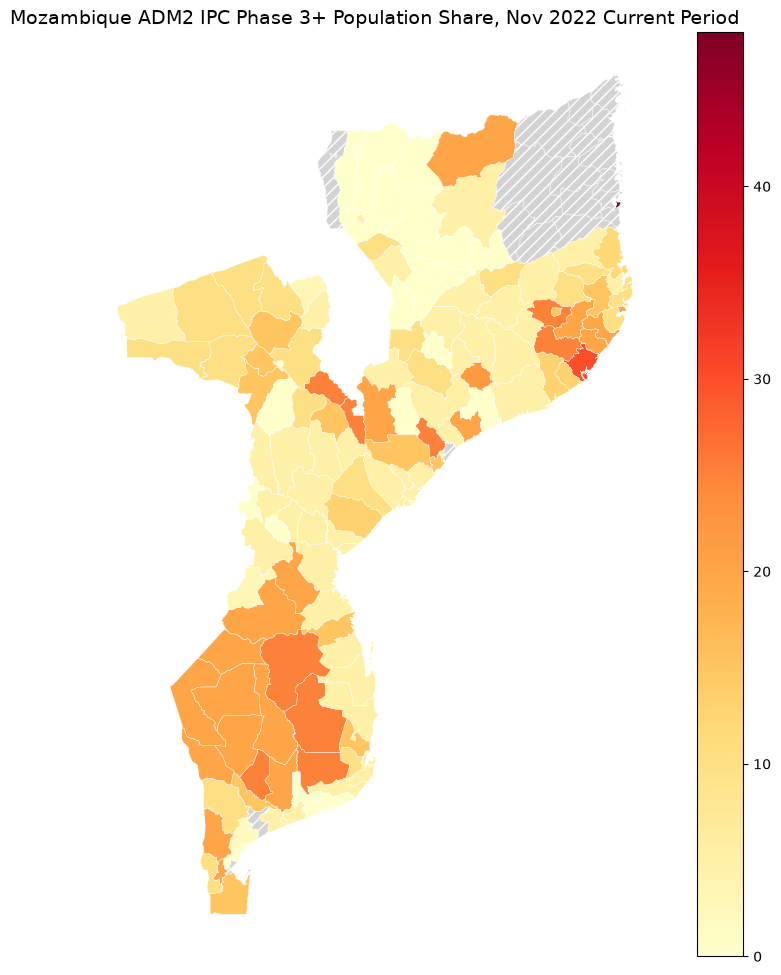

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

fused_gdf.plot(
    column="phase3plus_percent_current",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No usable IPC Phase 3+ value",
    },
)

ax.set_title(
    "Mozambique ADM2 IPC Phase 3+ Population Share, Nov 2022 Current Period",
    fontsize=14,
)

ax.set_axis_off()

plt.show()

In [10]:
missing_ipc = fused_gdf.loc[
    fused_gdf["phase3plus_percent_current"].isna(),
    [
        "shapeName",
        "province",
        "ipc_area",
        "has_ipc_2022_data",
        "under18_sum",
        "valid_cell_count",
        "current_from",
        "current_to",
    ],
].copy()

print("Districts missing usable Phase 3+ percent:", len(missing_ipc))

display(
    missing_ipc.sort_values(["province", "shapeName"], na_position="last")
)

Districts missing usable Phase 3+ percent: 22


,shapeName,province,ipc_area,has_ipc_2022_data,under18_sum,valid_cell_count,current_from,current_to
50,Ibo,Cabo Delgado,Ibo,False,5953.359375,1586,2022-10-01,2023-03-31
73,Macomia,Cabo Delgado,Macomia,False,63236.613281,18770,2022-10-01,2023-03-31
104,Meluco,Cabo Delgado,Meluco,False,21276.921875,14629,2022-10-01,2023-03-31
111,Mocimboa Da Praia,Cabo Delgado,Mocimboa da praia,False,68172.460938,18038,2022-10-01,2023-03-31
129,Muidumbe,Cabo Delgado,Muidumbe,False,53912.261719,14241,2022-10-01,2023-03-31
140,Nangade,Cabo Delgado,Nangade,False,49110.484375,24822,2022-10-01,2023-03-31
145,Palma,Cabo Delgado,Palma,False,34475.472656,18539,2022-10-01,2023-03-31
148,Quissanga,Cabo Delgado,Quissanga,False,28075.441406,7967,2022-10-01,2023-03-31
1,Ancuabe,NaN,NaN,False,92980.007812,51808,NaN,NaN
4,Balama,NaN,NaN,False,103711.765625,45246,NaN,NaN


## 17. Interactive dashboard handoff

This final section checks the optional interactive mapping dependencies and writes an HTML map that can support a lightweight dashboard or presentation demo. The map should use the same report-safe 2022 layer as the static figure.


In [ ]:
import importlib.util

required_interactive_packages = ["folium", "mapclassify", "branca"]
missing_interactive_packages = [
    package
    for package in required_interactive_packages
    if importlib.util.find_spec(package) is None
]

if missing_interactive_packages:
    raise ImportError(
        "Missing interactive-map packages: "
        + ", ".join(missing_interactive_packages)
        + ". Install the project environment from `requirements.txt` before running this section."
    )

print("Interactive map packages available:", required_interactive_packages)


In [22]:
from IPython.display import display

interactive_map = fused_gdf.explore(
    column="phase3plus_percent_current",
    cmap="YlOrRd",
    legend=True,
    tooltip=[
        "shapeName",
        "province",
        "ipc_area",
        "under18_sum",
        "phase3plus_percent_current",
        "under18_phase3plus_exposure_proxy_2022",
        "current_from",
        "current_to",
    ],
    popup=[
        "shapeName",
        "province",
        "ipc_area",
        "under18_sum",
        "valid_cell_count",
        "phase3plus_percent_current",
        "phase3plus_number_current",
        "population_analyzed_current",
        "under18_phase3plus_exposure_proxy_2022",
        "current_from",
        "current_to",
    ],
    tiles="CartoDB positron",
    style_kwds={
        "weight": 0.6,
        "color": "white",
        "fillOpacity": 0.75,
    },
    missing_kwds={
        "color": "lightgray",
        "fillOpacity": 0.5,
    },
    name="IPC Phase 3+ percent current, 2022 safe layer",
)

output_map_path = PROJECT_ROOT / "figures" / "moz_ipc_phase3plus_interactive_2022.html"

interactive_map.save(output_map_path)

print("Saved interactive map to:")
print(output_map_path)
print("File exists?", output_map_path.exists())

C:\Users\Cameron\Desktop\github\child_reach_spacial_project\.venv\Lib\site-packages\geopandas\explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")


Saved interactive map to:
C:\Users\Cameron\Desktop\github\child_reach_spacial_project\figures\moz_ipc_phase3plus_interactive_2022.html
File exists? True
